In [ ]:
from lib import util
import pandas as pd
import numpy as np
import lib.plotting_style as plt
import seaborn as sns

# data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv') 
data = util.load_data() 
dat_wa = pd.read_csv('C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\data_with_wa_scores.csv', sep=',')


In [173]:

filtered_data = dat_wa
filtered_data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,wa_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211.0
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187.0
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169.0
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148.0
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146.0


In [174]:
filtered_data["alter"] = filtered_data["jahr"] - filtered_data["geburtsjahr"]
filtered_data

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,wa_score,alter
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211.0,21
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187.0,24
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169.0,21
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148.0,25
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146.0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
211554,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck,545.0,13
211555,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale),543.0,14
211556,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg),542.0,14
211557,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde,541.0,14


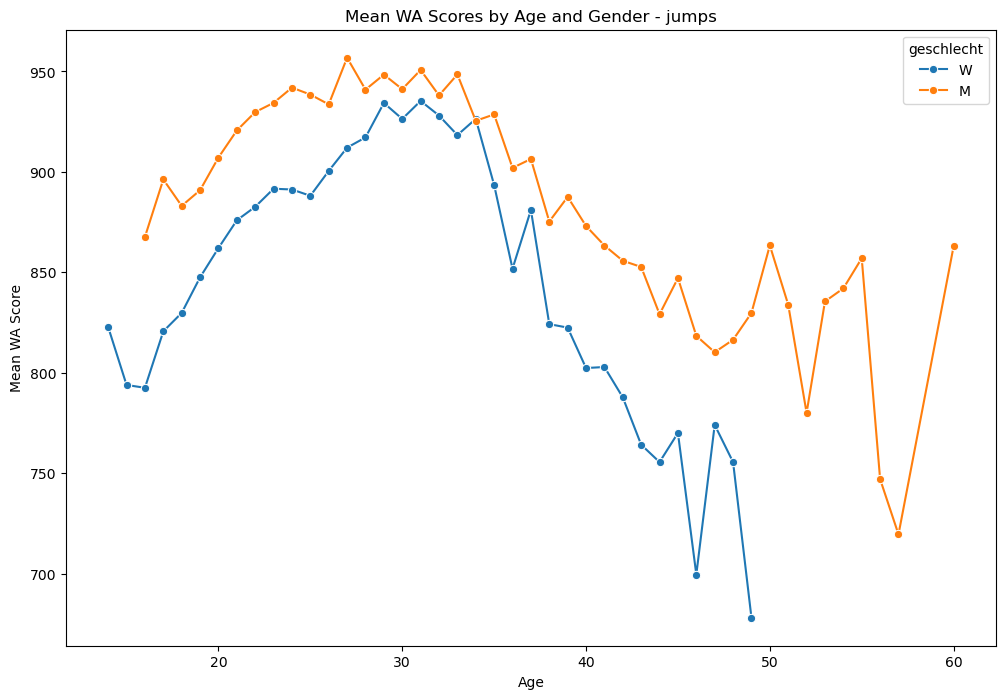

In [175]:
# exclude wa score over 1380 and under 25
filtered_data = filtered_data[(filtered_data["wa_score"] < 1380) & (filtered_data["wa_score"] > 25)]
# exclude age after 60
filtered_data = filtered_data[(filtered_data["alter"] <= 60) & (filtered_data["alter"] >= 14)]
filtered_data = filtered_data[(filtered_data["altersklasse"] == "Frauen") | (filtered_data["altersklasse"] == "Maenner")]
# only show for all running disciplines
throw = ["Speerwurf", "Diskuswurf", "Kugelstoßen", "Hammerwurf"]
filtered_data = filtered_data[filtered_data['disziplin'].isin(throw)]
# plot for mean wa score for altersklasse Maenner and Frauen per alter 
mean_wa_scores_age = filtered_data.groupby(['alter', 'geschlecht'])['wa_score'].mean().reset_index()
# plot standard deviation for altersklasse Maenner and Frauen per alter
std_wa_scores_age = filtered_data.groupby(['alter', 'geschlecht'])['wa_score'].std().reset_index()
plt.figure(figsize=(12, 8))
sns.lineplot(x='alter', y='wa_score', hue='geschlecht', data=mean_wa_scores_age, marker='o')
plt.xlabel('Age')
plt.ylabel('Mean WA Score')
plt.title('Mean WA Scores by Age and Gender - jumps')
plt.show()

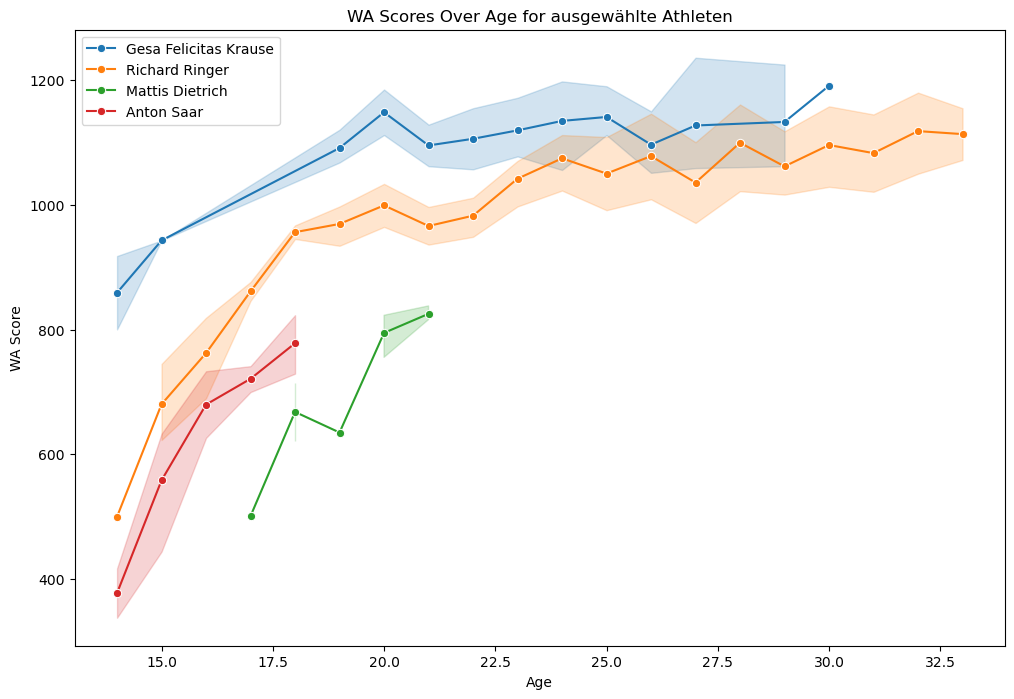

In [176]:
gesa = dat_wa[dat_wa["name"] == "Gesa Felicitas Krause"]
richard = dat_wa[dat_wa["name"] == "Richard Ringer"]
mattis = dat_wa[dat_wa["name"] == "Mattis Dietrich"]
anton = dat_wa[dat_wa["name"] == "Anton Saar"]

# Plot all wa Scores for Gesa Felicitas Krause and the age
plt.figure(figsize=(12, 8))
sns.lineplot(x='alter', y='wa_score', data=gesa, marker='o', label='Gesa Felicitas Krause')
sns.lineplot(x='alter', y='wa_score', data=richard, marker='o', label='Richard Ringer')
sns.lineplot(x='alter', y='wa_score', data=mattis, marker='o', label='Mattis Dietrich')
sns.lineplot(x='alter', y='wa_score', data=anton, marker='o', label='Anton Saar')

plt.xlabel('Age')
plt.ylabel('WA Score')
plt.title('WA Scores Over Age for ausgewählte Athleten')
plt.show()

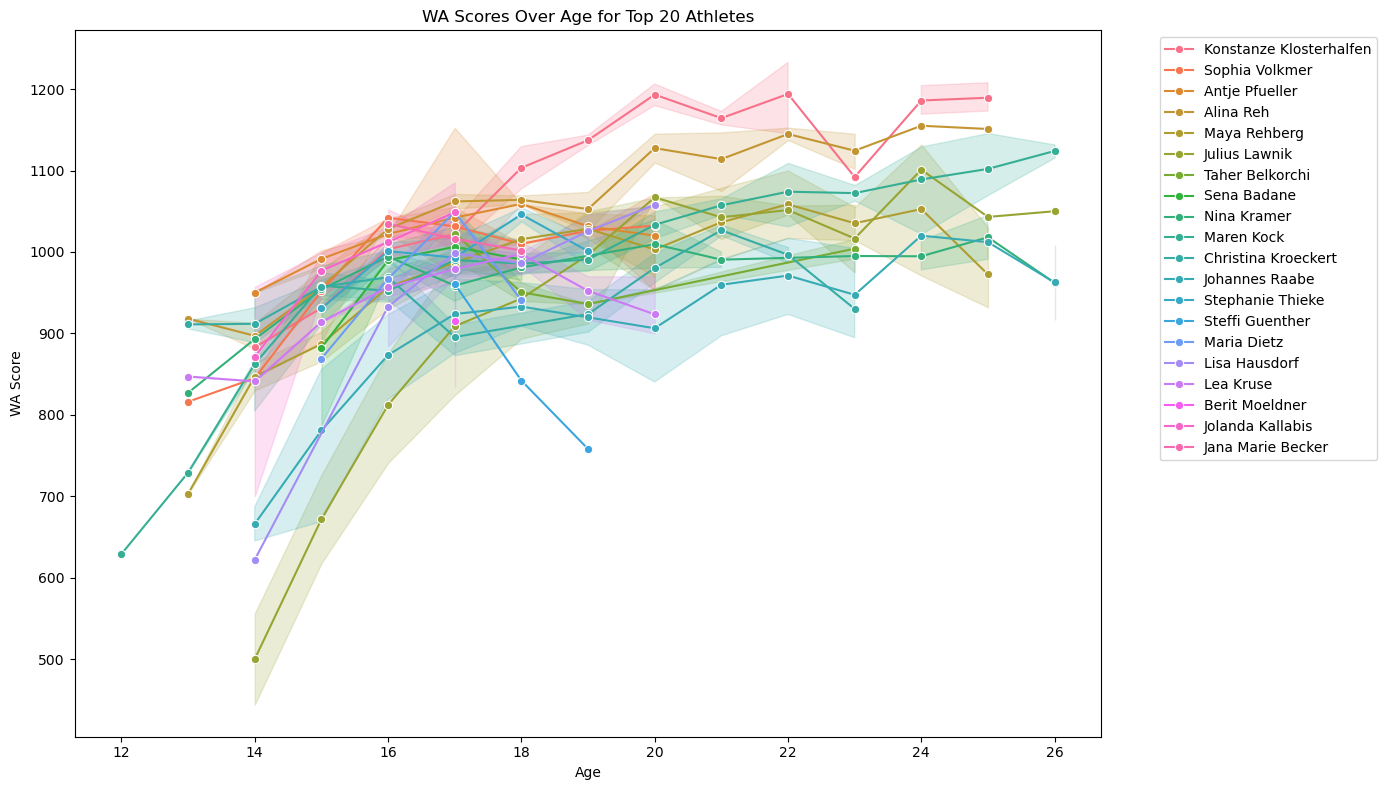

In [ ]:
import pandas as pd
import seaborn as sns
import lib.plotting_style as plt


dat_filtered = dat_wa[dat_wa['alter'] < 40]


dat_filtered = dat_filtered[dat_filtered['wa_score'] < 1380]

dat_filtered = dat_filtered[dat_filtered['disziplin'] == '1500 m']

dat_filtered = dat_filtered[dat_filtered['altersklasse'] == '18']


# Get top 10 athletes by max wa_score in filtered data
top_10_names = (
    dat_filtered.groupby('name')['wa_score']
    .max()
    .sort_values(ascending=False)
    .head(20)
    .index
)

# Filter the original data (or filtered data) for these top athletes
top_20_data = dat_wa[dat_wa['name'].isin(top_10_names)]

# Filter the data for those athles
plt.figure(figsize=(14, 8))

sns.lineplot(
    x='alter', 
    y='wa_score', 
    hue='name',  # automatically gives each athlete a different color
    data=top_20_data, 
    marker='o'
)

plt.xlabel('Age')
plt.ylabel('WA Score')
plt.title('WA Scores Over Age for Top 20 Athletes')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside plot
plt.tight_layout()
plt.show()
